**Mounting the Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : f"{x:0.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update( {
    "axes.titlesize" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize" : 8,
    "ytick.labelsize" : 8,
})

RANDOM_STATE = 42
TARGET_COL = "median_house_value"

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/housing (1).csv')

### Exploratory Data Analysis

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [ ]:
df.shape

(20640, 10)

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = df.select_dtypes(include=["object"]).columns.to_list()

In [ ]:
#missing values
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
#checking any encoded values
for col in df.columns:
  print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.250    128
-118.370    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [ ]:
#checking any duplicated rows
df.duplicated().sum().sum()

np.int64(0)

In [ ]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


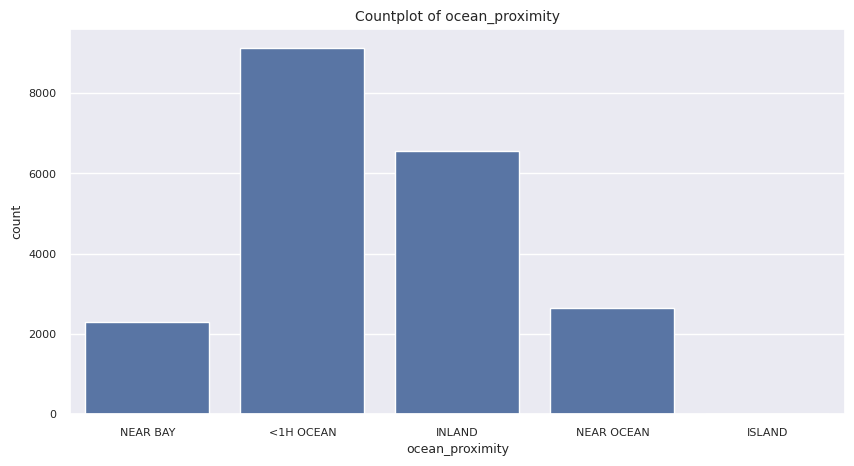

In [ ]:
#countplot for categorical columns
for col in cat_cols:
  plt.figure(figsize=(10,5))
  sns.countplot(data=df, x=col)
  plt.title(f"Countplot of {col}")
  plt.show()

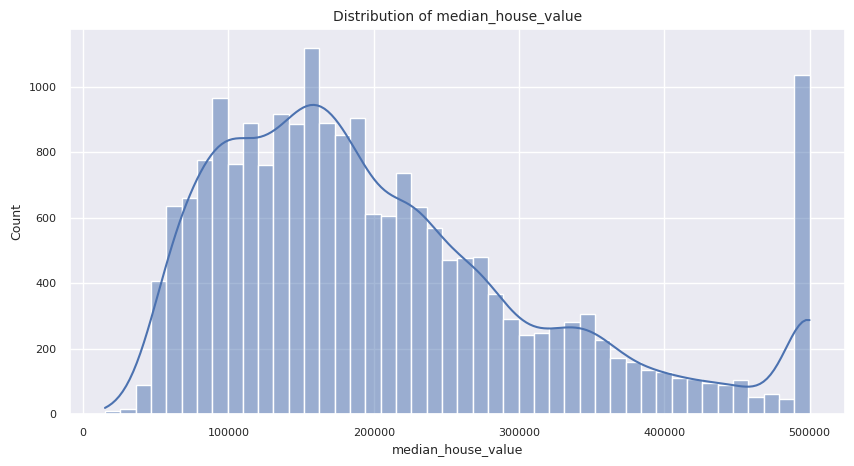

In [ ]:
# distribution of target column
plt.figure(figsize=(10,5))
sns.histplot(data=df, x=TARGET_COL, kde=True)
plt.title(f"Distribution of {TARGET_COL}")
plt.show()

In [ ]:
df[TARGET_COL].value_counts().sort_values(ascending=False).head(10)

,count
median_house_value,
500001.000,965
137500.000,122
162500.000,117
112500.000,103
187500.000,93
225000.000,92
350000.000,79
87500.000,78
275000.000,65


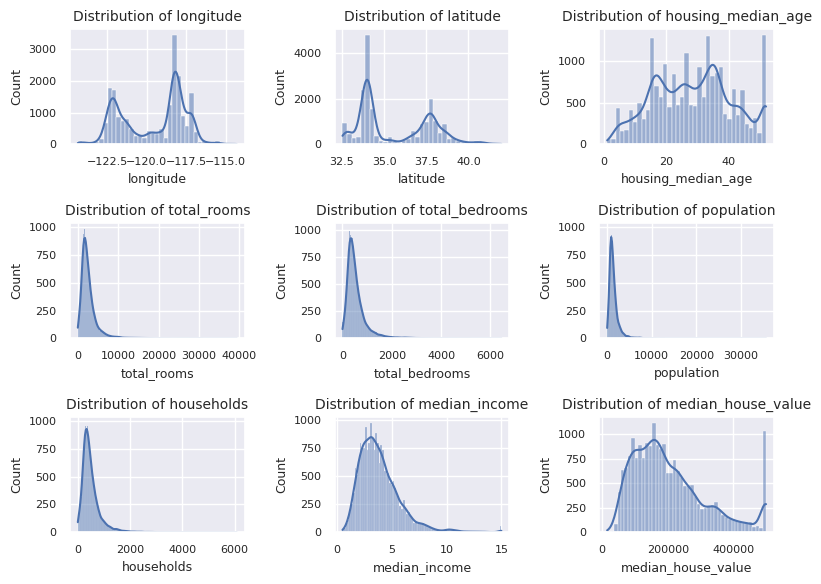

In [ ]:
# distribution of all the numerical values
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(data=df, x=col, kde=True, ax=axes[i])
  axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

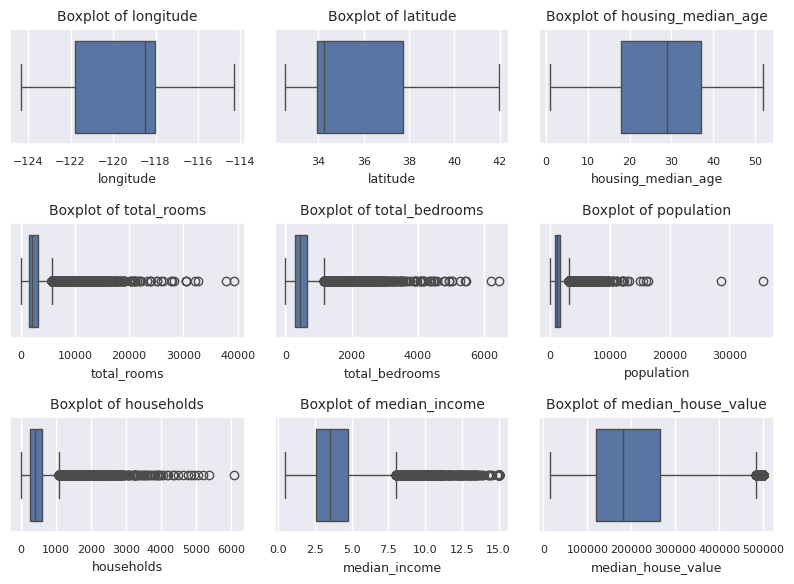

In [ ]:
# boxplot for checking outliers or where the data lies
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.boxplot(data=df, x=col, ax=axes[i])
  axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

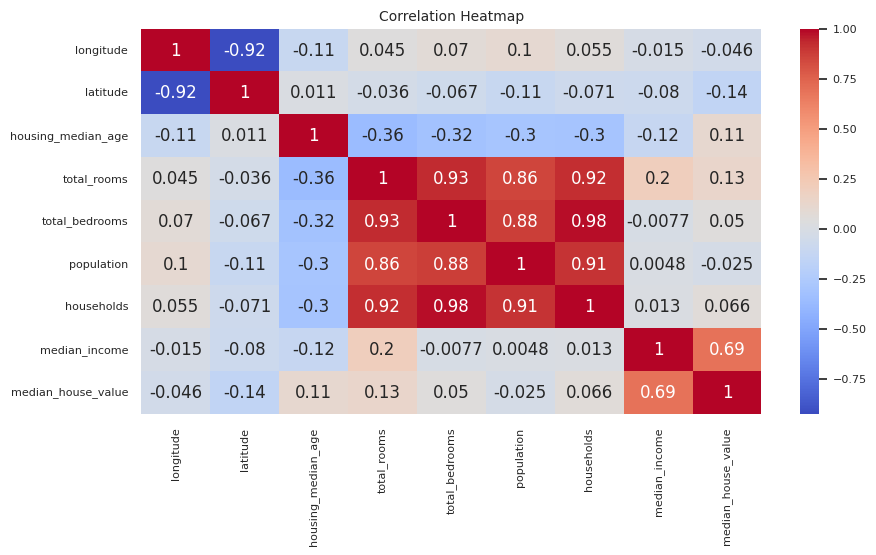

In [ ]:
#heatmap
plt.figure(figsize=(10,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# checking correlation with target column of all the numerical columns
print("Correlation with target variable:")
print(df[num_cols].corr()[TARGET_COL].sort_values(ascending=False).head(10))

Correlation with target variable:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


### Key insights from EDA
1. The dataset contains 20,640 rows and 10 columns.
2. The total_bedrooms column has 207 missing values that require imputation.
3. There are no duplicate rows in the dataset.
4. The median_house_value is capped at 500,001, which may bias models predicting high-end prices.
5. median_income shows the highest positive correlation (0.688) with median_house_value.

### Preprocessing and Evaluation plan
1. Median imputation for missing values in total bedrooms.
2. One-hot encoding for the ocean proximity.
3. Scaling numerical columns to to ensure it contribute equally to the model.
4.

**Data Preprocessing**

In [ ]:
# seperating data into features and target
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

In [ ]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [ ]:
y.head()

,median_house_value
0,452600.000
1,358500.000
2,352100.000
3,341300.000
4,342200.000


In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 9)
(4128, 9)
(16512,)
(4128,)


In [ ]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.to_list()
categorical_features = X_train.select_dtypes(include=["object"]).columns.to_list()

print(numerical_features)
print(categorical_features)

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# basic model without cv and optimization
pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
['ocean_proximity']


In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

In [ ]:
train_data_pred = pipeline.predict(X_train)
test_data_pred = pipeline.predict(X_test)

In [ ]:
train_data_rmse = root_mean_squared_error(y_train, train_data_pred)
test_data_rmse = root_mean_squared_error(y_test, test_data_pred)
train_data_mae = mean_absolute_error(y_train, train_data_pred)
test_data_mae = mean_absolute_error(y_test, test_data_pred)
train_data_r2 = r2_score(y_train, train_data_pred)
test_data_r2 = r2_score(y_test, test_data_pred)

print(f"Train data RMSE: {train_data_rmse}")
print(f"Test data RMSE: {test_data_rmse}")
print(f"Train data MAE: {train_data_mae}")
print(f"Test data MAE: {test_data_mae}")
print(f"Train data R2: {train_data_r2}")
print(f"Test data R2: {test_data_r2}")

Train data RMSE: 68433.93736666226
Test data RMSE: 70059.19333925014
Train data MAE: 49594.84209472437
Test data MAE: 50670.48923565361
Train data R2: 0.6496648627123223
Test data R2: 0.6254382675296266


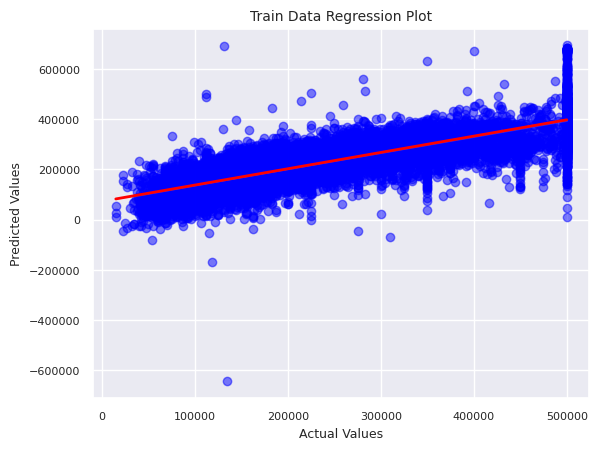

In [ ]:
sns.regplot(x=y_train, y=train_data_pred, scatter_kws={"color": "blue", "alpha": 0.5}, line_kws={"color": "red", "linewidth": 2})
plt.title("Train Data Regression Plot")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

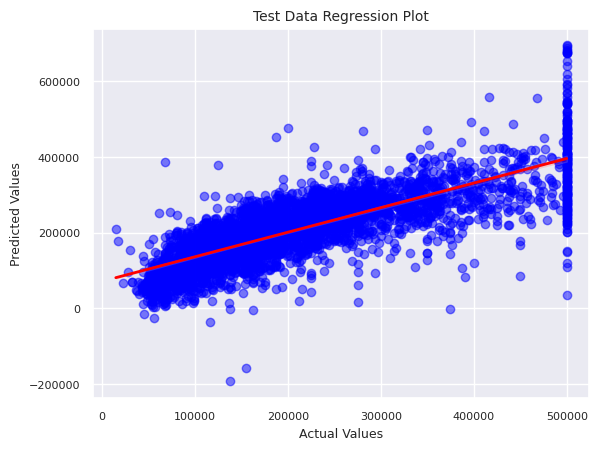

In [ ]:
sns.regplot(x=y_test, y=test_data_pred
            , scatter_kws={"color": "blue", "alpha": 0.5}, line_kws={"color": "red", "linewidth": 2})
plt.title("Test Data Regression Plot")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

### Model Selection & Optimization

In [ ]:
#models to try
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "Ridge": Ridge(random_state=RANDOM_STATE, max_iter=10000),
    "Random Forest": RandomForestRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor()
}

# evaluations
evaluations = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [ ]:
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

In [57]:
rows=[]

for name, model in models.items():
  pipe = Pipeline(steps=[
      ("preprocess", preprocess),
      ("model", model)
  ])
  scores = cross_validate(pipe, X_train, y_train, cv=kf, scoring=evaluations, n_jobs=-1)
  # print(scores)
  rows.append(
      {
          "Model": name,
          "RMSE": -scores["test_RMSE"].mean(),
          "MAE": -scores["test_MAE"].mean(),
          "R2": scores["test_R2"].mean()
      }
  )

In [59]:
#sorting on the basis of lowest rmse
model_eval = pd.DataFrame(rows).sort_values(by="RMSE", ascending=True)

In [64]:
#selecting best model
best_model = model_eval["Model"].iloc[0]
lowest_RMSE = model_eval["RMSE"].iloc[0]

print("Best model", best_model)
print("Lowest RMSE", lowest_RMSE.round(2))

Best model HistGradientBoosting
Lowest RMSE 48138.94


*Best model -> HistGradientBoodtingRegressor*

In [65]:
# creating pipeline
hgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
])

In [66]:
param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_iter": [100, 200, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0],
    "model__max_bins": [255, 128]
}

In [68]:
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV
grid_search = GridSearchCV(
    hgb_pipe,
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# View best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best Parameters: {'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_bins': 255, 'model__max_depth': None, 'model__max_iter': 500, 'model__min_samples_leaf': 50}
Best RMSE: 47047.11


**retraining with best parameters(hyperparameter tuning)**

In [70]:
hgb_pipe.set_params(**grid_search.best_params_)

hgb_pipe.fit(X_train, y_train)

pred = hgb_pipe.predict(X_test)

In [72]:
# evaluation
test_final_rmse = root_mean_squared_error(y_test, pred)
test_final_mae = mean_absolute_error(y_test, pred)
test_final_r2 = r2_score(y_test, pred)

print(f"Test RMSE: {test_final_rmse:.2f}")
print(f"Test MAE: {test_final_mae:.2f}")
print(f"Test R2: {test_final_r2:.2f}")

Test RMSE: 46242.03
Test MAE: 30948.57
Test R2: 0.84


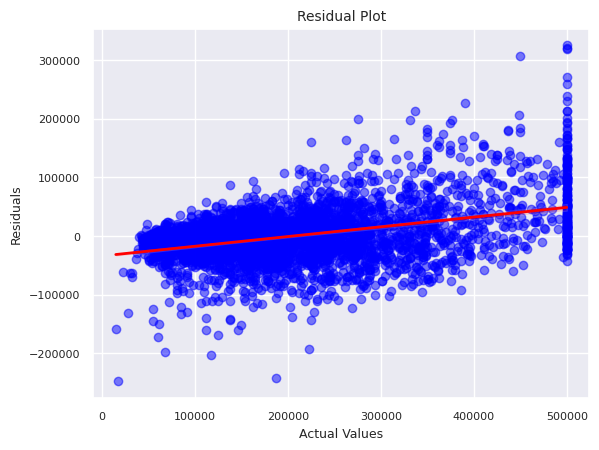

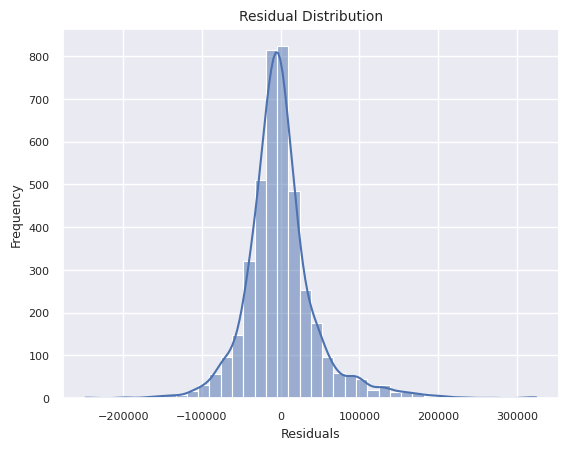

In [76]:
#residual plot
residuals = y_test - pred

sns.regplot(x=y_test, y=residuals, scatter_kws={"color": "blue", "alpha": 0.5}, line_kws={"color": "red", "linewidth": 2})
plt.title("Residual Plot")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.show()

sns.histplot(data=residuals, kde=True, bins=40)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

**making a predictive system**

In [81]:
def house_price_predict(
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:
   new_row = pd.DataFrame([{
       "longitude": longitude,
       "latitude": latitude,
       "housing_median_age": housing_median_age,
       "total_rooms": total_rooms,
       "total_bedrooms": total_bedrooms,
       "population": population,
       "households": households,
       "median_income": median_income,
       "ocean_proximity": ocean_proximity
   }])
   return float(hgb_pipe.predict(new_row)[0])


In [82]:
example = house_price_predict(
    longitude=-122.23,
    latitude=37.88,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
    )
print("\nExample prediction: ", round(example,2))


Example prediction:  435266.65
